# Optimizing Models with Error Minimization

In [25]:
# Importing packages!
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

## Why Optimize Models?

When creating a simple model by hand, we often approximate a function that best fits the data we're working with. However, this model may not be the most accurate, and might not best fit the data. Therefore, it's important to **optimize** a model. Optimizing often involves fine-tuning the model to create the best-fitting function possible. If you optimize your model, then you can understand your data better and predict potential values more effectively and accurately.

## An Overview of Error Minimization

When we create a linear prediction model with a best-fit line, we don't create a perfect estimate of the data. Rather, our models contain **errors**, where our predicted value is off from the true value by some number. To optimize a model, we aim to minimize these errors, and thus create a model that best fits the data. 

We can utilize the **root mean squared error** for optimizing our model. The root mean squared error is an overall measure of the rough size of the errors. Because errors can be positive or negative, the squared errors are used to prevent cancellation, and because the mean squared error is hard to interpret, the square root is taken. By minimizing the root mean squared error, we can optimize our model.

## Optimizing a Linear Prediction Model

We'll go through the steps of optimizing a linear prediction model using the Old Faithful dataset.

The Old Faithful dataset contains information on various observed eruptions of the Old Faithful Geyser in Yellowstone National Park. The old faithful dataset contains two columns, `eruptions` and `waiting`. The `eruptions` column contains the duration of an observed eruption, while the `waiting` column represents the duration in minutes until the next eruption.

In [2]:
old_faithful = pd.read_csv("old_faithful.csv")
old_faithful

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85
...,...,...
267,4.117,81
268,2.150,46
269,4.417,90
270,1.817,46


### Visualizing the Data

Let's plot the Old Faithful data to see if there are any trends in the data.

Text(0.5, 1.0, 'Eruption duration vs waiting time')

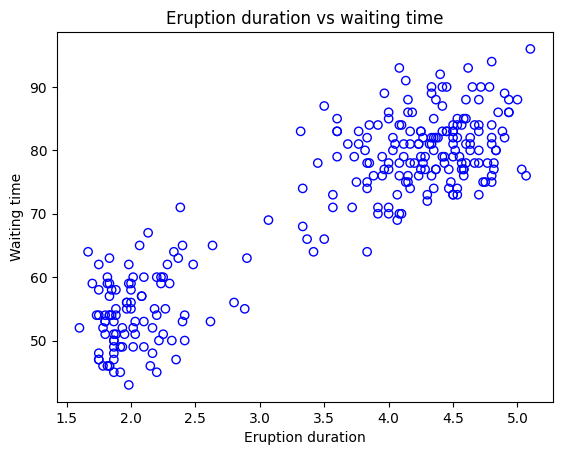

In [49]:
# Creates a figure for plotting
fig, ax1 = plt.subplots()

# Plots the Old Faithful data
ax1.scatter(old_faithful['eruptions'], old_faithful['waiting'], edgecolors = 'b', facecolors = 'none')

# Labels the plot
ax1.set_xlabel('Eruption duration')
ax1.set_ylabel('Waiting time')
ax1.set_title("Eruption duration vs waiting time")

There seems to be a positive trend in the data.

### Plotting Raw Error

We can visualize the raw error, which is done by subtracting the model y-values from the true y-values to calculate the error, then plotting lines leading from the observed value points to the best-fit line. Let's make a function called `plot_raw_error` that does this.

In [40]:
def plot_raw_error(xvls, yvls, model):

    # Creates a figure for plotting
    fig, ax3 = plt.subplots()
    
    # Plots the raw data points
    ax3.scatter(xvls, yvls, edgecolors = 'b', facecolors = 'none')

    # Gets the model y-values
    model_yvls = xvls * model[0] + model[1]

    # Plots the best-fit line
    ax3.plot(xvls, model_yvls)

    # Calculates the raw error values
    raw_error_values = yvls-model_yvls

    # Plots the raw error values
    ax3.plot([xvls, xvls], [yvls, yvls - raw_error_values], 'c')

    # Labels the plot
    ax3.set_xlabel('Eruption duration')
    ax3.set_ylabel('Waiting time')
    ax3.set_title('Raw Error for a Model')


Let's plot the errors with a random model.

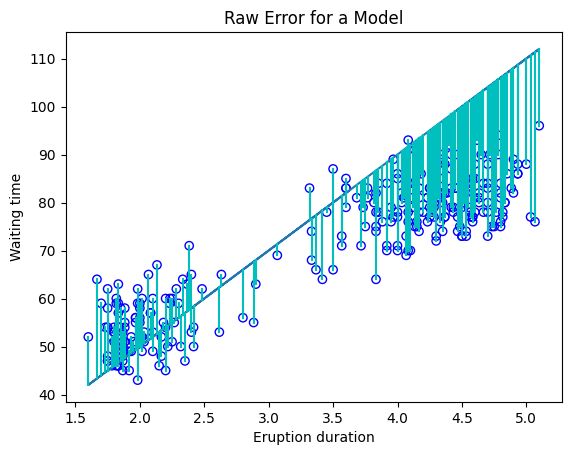

In [50]:
# Creates a random model with a slope of 20 and an intercept of 10
random_model = [20, 10]
# Plots the raw error for the random model
plot_raw_error(old_faithful['eruptions'], old_faithful['waiting'], random_model)

The error lines are fairly long, so this model might not be the best fit.

### Calculating Root Mean Squared Error

Now, we'll calculate the root mean squared error to help quantify the fit of our model. This is done by taking the mean of the squared error values, then taking the square root. We'll create the function `calc_rms_error()` to calculate it.

In [52]:
# Gets the x- and y-values
xvls = old_faithful['eruptions']
yvls = old_faithful['waiting']

def calc_rms_error(model):

    # Calculates the model y-values
    model_yvls = xvls * model[0] + model[1]

    # Calculates the raw error values
    raw_error_values = yvls - model_yvls

    # Calculates the root mean squared error
    rms_error = np.sqrt(np.mean(raw_error_values ** 2))

    # Returns the root mean square error
    return rms_error

Let's calculate the root mean squared error for our random model.

In [53]:
print(f'The RMS error for the random model is {calc_rms_error(random_model)}')

The RMS error for the random model is 14.991246220221123


The rms error isn't that low, so this model, again, doesn't seem like a great fit.

### Optimizing RMS Error

The `minimize()` function from `scipy.optimize` can be used to minimize our RMS error. The `minimize()` function takes a function and the parameters as an input, then minimizes the values for it. We'll minimize our model by using `minimize()` on our `calc_rms_error` function.

In [54]:
# Calculates the optimized model fit
model_fit = opt.minimize(calc_rms_error, [15, 20])
opt_model = model_fit['x']
print(f'The model fit is {opt_model}')

The model fit is [10.72963539 33.47440872]


Let's see how the RMS error for the optimized model compares to our random model.

In [55]:
print(f'The rms error for the random model is {calc_rms_error(random_model)}')
print(f'The rms error for the optimized model is {calc_rms_error(opt_model)}')

The rms error for the random model is 14.991246220221123
The rms error for the optimized model is 5.89222663590517


The RMS error is lower for the optimized model, so it's a better fit!

Let's plot this optimized model using our `plot_raw_error` function.

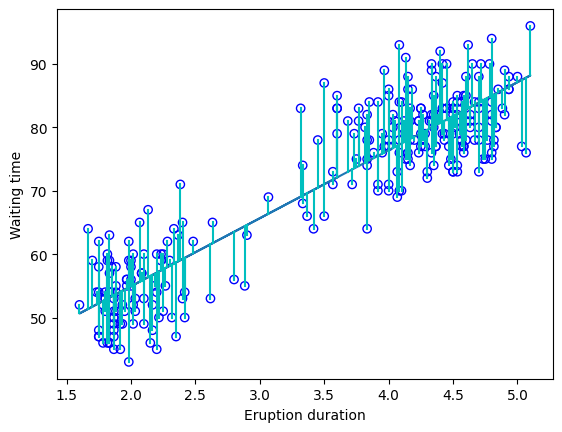

In [28]:
plot_raw_error(xvls, yvls, opt_model)

How does this compare to our random model? Let's plot it to see.

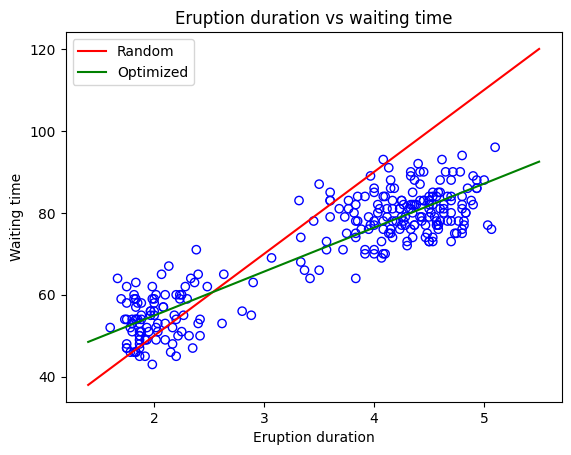

In [58]:
# Creates a figure for plotting
fig, ax4 = plt.subplots()

# Plots the Old Faithful data
ax4.scatter(old_faithful['eruptions'], old_faithful['waiting'], edgecolors = 'b', facecolors = 'none')

# Generates 30 x-values
xvls = np.linspace(1.4, 5.5, 30)
# Calculates the y-values using our random slope and intercept values
random_yvls = random_model[0] * xvls + random_model[1]
# Calculates the y-values using our optimized slope and intercept
opt_yvls = opt_model[0] * xvls + opt_model[1]
# Plots the best-fit line for the random model
ax4.plot(xvls, random_yvls, c = 'r', label = 'Random')
# Plots the best-fit line for the optimized model
ax4.plot(xvls, opt_yvls, c = 'g', label = 'Optimized')

# Labels the plot
ax4.set_xlabel('Eruption duration')
ax4.set_ylabel('Waiting time')
ax4.set_title("Eruption duration vs waiting time")
ax4.legend()

The optimized model is visually a better fit as well.

### Making Predictions with the Optimized Model

We can use the optimized model to create more accurate predictions.

In [39]:
# Waiting time for an eruption when eruption time is 6
eruption_time = 6
waiting = opt_model[0]*eruption_time + opt_model[1]
print(f'The predicted waiting time for an eruption duration of 6 is {waiting}.')

The predicted waiting time for an eruption duration of 6 is 97.85222107012504.
